In [47]:
import yaml
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, ks_2samp
from scipy.stats import wasserstein_distance as w1dist, pearsonr
from factor_model import load_model
from scenario_generator import *

with open("cfg.yaml") as f:
    _exp = yaml.safe_load(f)["experiment_name"]
PREFIX = f"model/{_exp}"
with open(f"{PREFIX}/cfg.yaml") as f:
    _cfg = yaml.safe_load(f)

NUM_GENERATE = _cfg["num_generate"]
rng = np.random.default_rng(42)

In [48]:
train_model = load_model(f"{PREFIX}")
test_model = load_model(f"{PREFIX}/test")
print(PREFIX)

model/regression


In [49]:
R_df = pd.read_parquet(train_model.data_source)
R_testdf = pd.read_parquet(test_model.data_source)
common_stocks = np.intersect1d(R_df['csecid'].unique(), R_testdf['csecid'].unique()) # common stocks that both in the training DS and the testing DS
col_indices_test = np.searchsorted(np.sort(R_testdf['csecid'].unique()), common_stocks)
col_indices = np.searchsorted(np.sort(R_df['csecid'].unique()), common_stocks) # indices of stocks in our training data (before filtering)
R_testdf = R_testdf[R_testdf['csecid'].isin(common_stocks)]
R_df = R_df[R_df['csecid'].isin(common_stocks)]
R_train = R_df.pivot_table(index="date", columns="csecid", values="returns").values # R_train / R_test is filtered to only include the common stocks and there column are aligned
R_test = R_testdf.pivot_table(index="date", columns="csecid", values="returns").values

In [50]:
"""
R_df = pd.read_parquet(train_model.data_source)
assert np.array_equal(R_train.columns[col_indices], common_stocks), "Column indices do not match common stocks"
R_train = R_train.values
# test if the common stocks are correctly aligned
R_train = R_df.pivot_table(index="date", columns="csecid", values="returns")
R_test = R_testdf.pivot_table(index="date", columns="csecid", values="returns")
assert R_test.columns.equals(R_train.columns), "Columns do not match common stocks"
"""

'\nR_df = pd.read_parquet(train_model.data_source)\nassert np.array_equal(R_train.columns[col_indices], common_stocks), "Column indices do not match common stocks"\nR_train = R_train.values\n# test if the common stocks are correctly aligned\nR_train = R_df.pivot_table(index="date", columns="csecid", values="returns")\nR_test = R_testdf.pivot_table(index="date", columns="csecid", values="returns")\nassert R_test.columns.equals(R_train.columns), "Columns do not match common stocks"\n'

In [51]:
diffusionScenario = ScenarioGenerator(train_model, DiffusionSampler(f"{PREFIX}/checkpoints/{_cfg['ckpt_name']}.pt"))
R_gen = diffusionScenario.stock_generate(NUM_GENERATE)[:, col_indices]
R_gen.shape

(4096, 1924)

In [52]:
# get the baseline sample after filtering
row_idx = rng.choice(R_train.shape[0], size=NUM_GENERATE, replace=False)
R_rs = R_train[row_idx, :]
R_test = R_testdf.pivot_table(index="date", columns="csecid", values="returns").values
gaussionScenario = ScenarioGenerator(train_model, GaussianSampler(train_model.F, diffusionScenario.sampler.scaler, guidance_scale=5))
R_gaussian = gaussionScenario.stock_generate(NUM_GENERATE)[:, col_indices]

print(f"Train returns: {R_train.shape}  NaN fraction: {np.isnan(R_train).mean():.2%}")
print(f"Test returns:  {R_test.shape}   NaN fraction: {np.isnan(R_test).mean():.2%}")
print(f"Resample returns: {R_rs.shape}  NaN fraction: {np.isnan(R_rs).mean():.2%}")
print(f"Gaussion returns: {R_gaussian.shape} NaN fraction: {np.isnan(R_gaussian).mean():.2%}")

Train returns: (6262, 1924)  NaN fraction: 39.33%
Test returns:  (261, 1924)   NaN fraction: 4.27%
Resample returns: (4096, 1924)  NaN fraction: 39.35%
Gaussion returns: (4096, 1924) NaN fraction: 0.00%


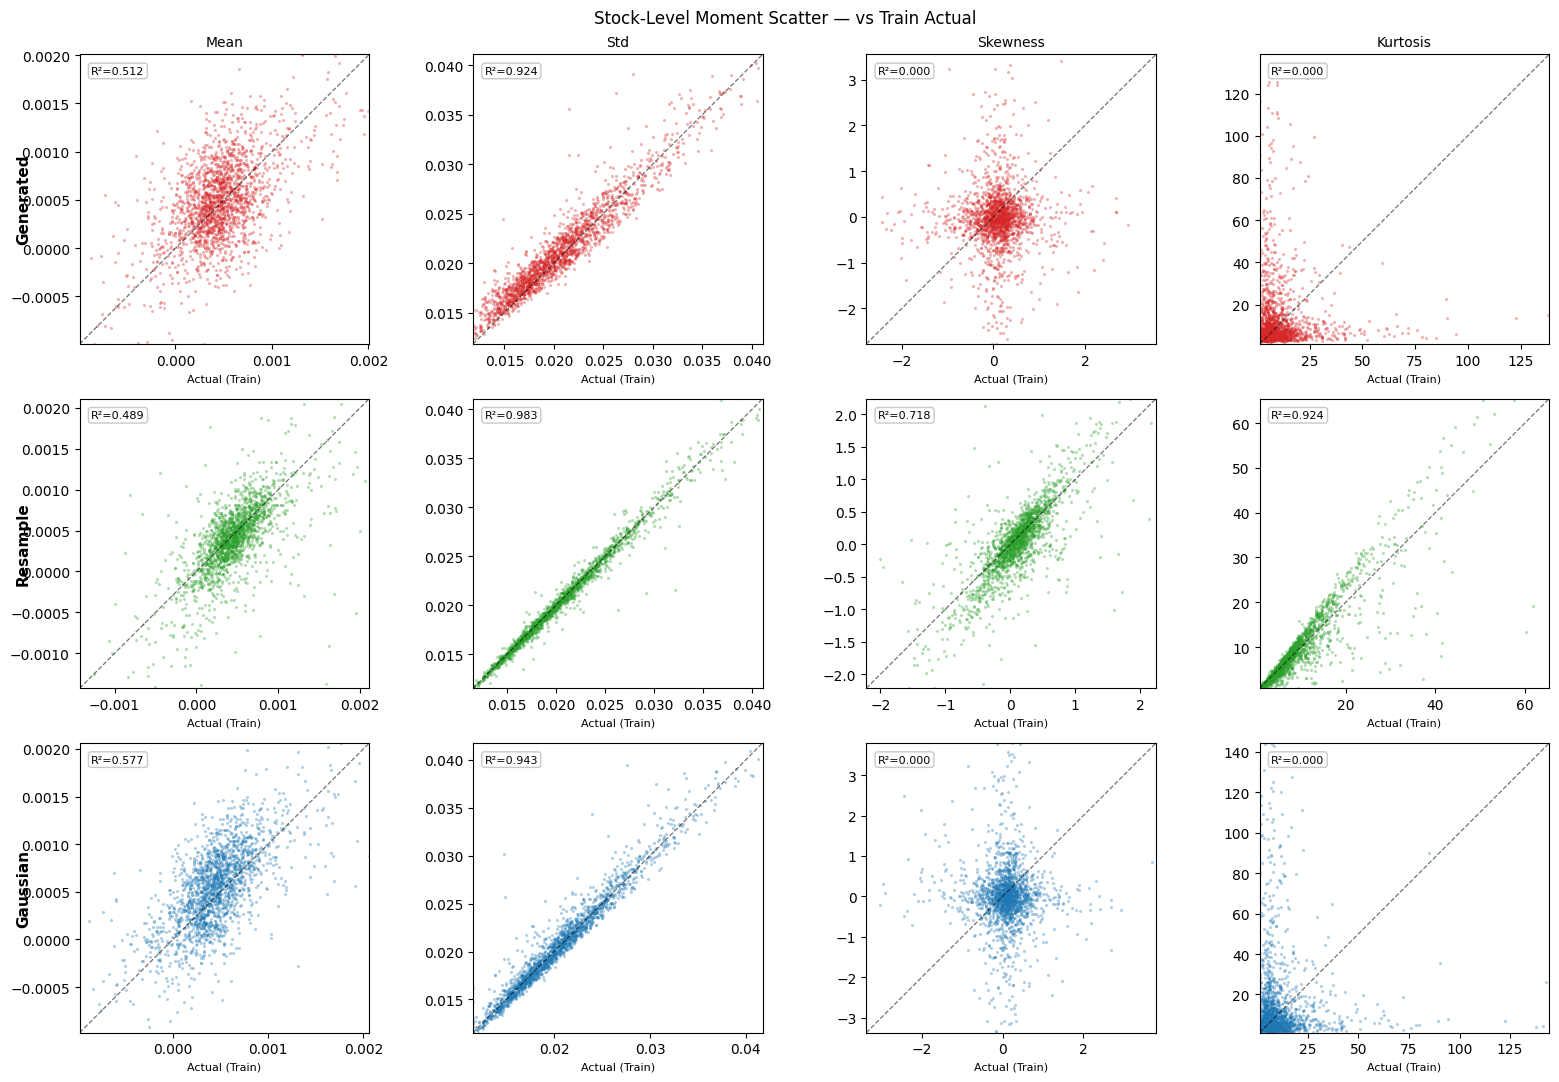

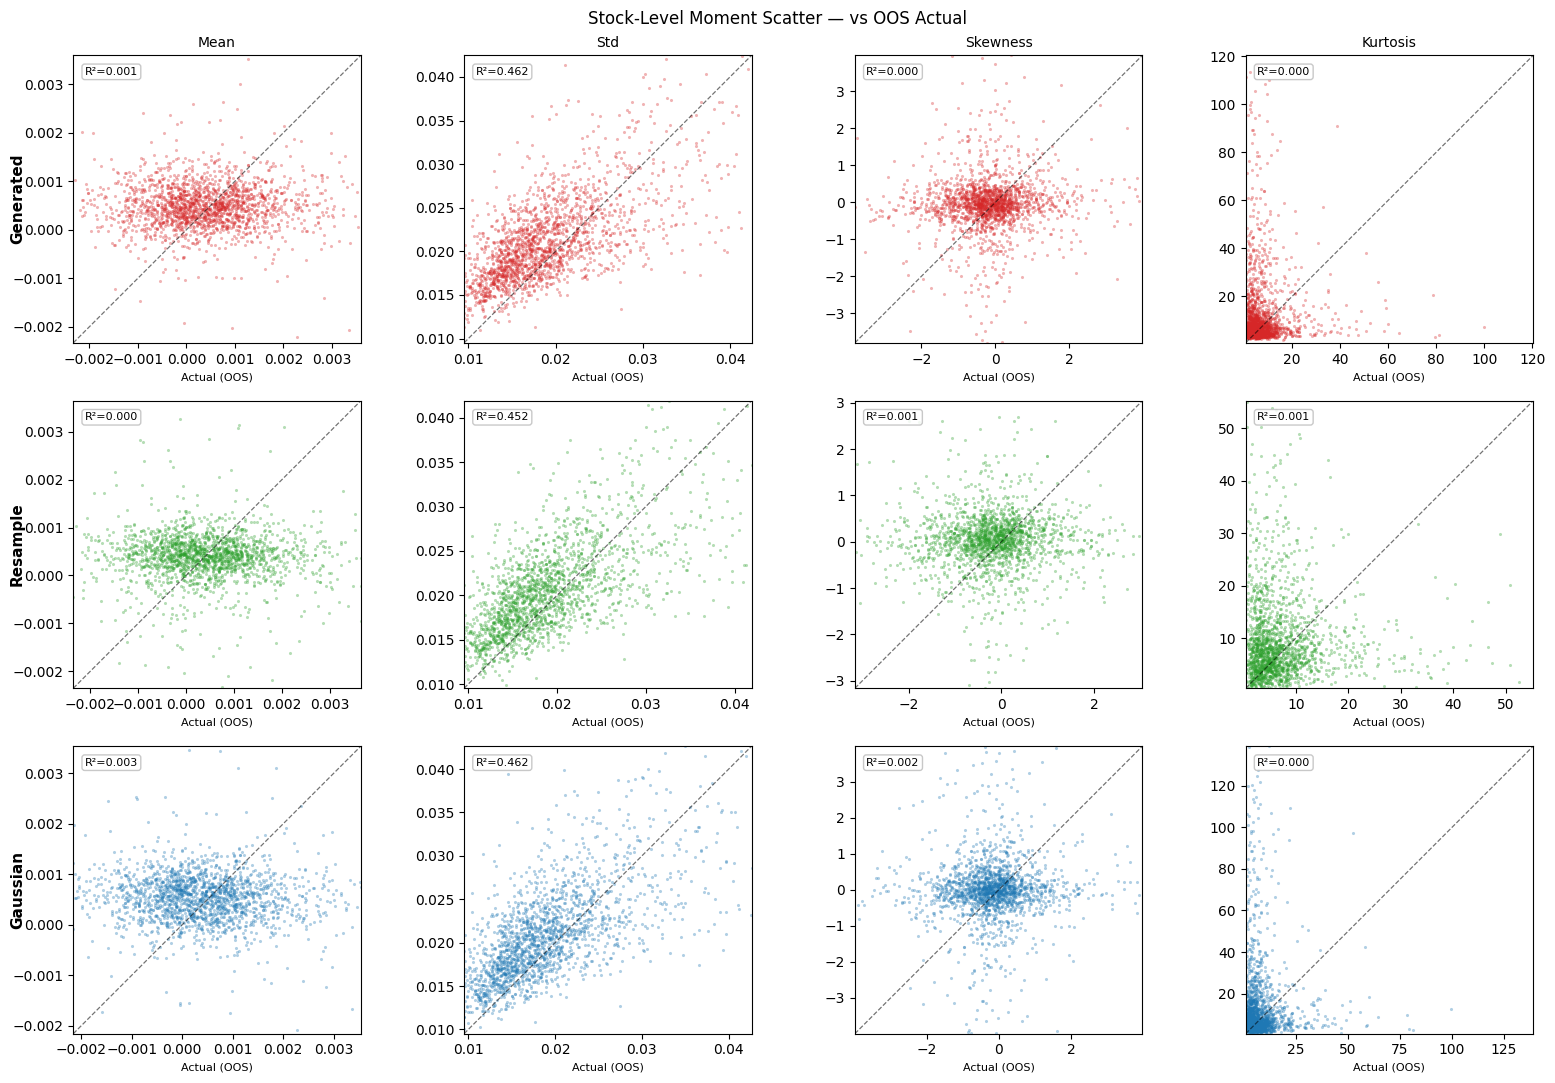

In [53]:
## Stock-Level Moment Scatter Plots
MOMENTS = {
    "Mean":     lambda X: np.nanmean(X, axis=0),
    "Std":      lambda X: np.nanstd(X, axis=0),
    "Skewness": lambda X: skew(X, axis=0, nan_policy="omit"),
    "Kurtosis": lambda X: kurtosis(X, axis=0, nan_policy="omit"),
}

m_actual_tr  = {k: fn(R_train) for k, fn in MOMENTS.items()}
m_actual_oos = {k: fn(R_test)  for k, fn in MOMENTS.items()}
m_gen        = {k: fn(R_gen)       for k, fn in MOMENTS.items()}
m_rs         = {k: fn(R_rs)        for k, fn in MOMENTS.items()}
m_gs         = {k: fn(R_gaussian)  for k, fn in MOMENTS.items()}

MODELS = [
    ("Generated", m_gen, "#d62728"),
    ("Resample",  m_rs,  "#2ca02c"),
    ("Gaussian",  m_gs,  "#1f78b4"),
]

def _moment_scatter(actual_label, m_actual, fig_title):
    fig, axes = plt.subplots(3, 4, figsize=(16, 11))
    for row, (model_label, m_pred, color) in enumerate(MODELS):
        for col, (mname, _) in enumerate(MOMENTS.items()):
            ax = axes[row, col]
            x = m_actual[mname]
            y = m_pred[mname]
            mask = np.isfinite(x) & np.isfinite(y)

            lo = np.percentile(np.concatenate([x[mask], y[mask]]), 1)
            hi = np.percentile(np.concatenate([x[mask], y[mask]]), 99)

            ax.scatter(x[mask], y[mask], s=5, alpha=0.35, linewidths=0, color=color)
            ax.plot([lo, hi], [lo, hi], "k--", lw=0.9, alpha=0.55)

            r, _ = pearsonr(x[mask], y[mask])
            ax.text(0.04, 0.96, f"R²={r**2:.3f}",
                    transform=ax.transAxes, fontsize=8, va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                              edgecolor="0.75", alpha=0.85))

            ax.set_xlim(lo, hi)
            ax.set_ylim(lo, hi)
            ax.set_aspect("equal")
            ax.set_xlabel(f"Actual ({actual_label})", fontsize=8)
            if row == 0:
                ax.set_title(mname, fontsize=10)

        axes[row, 0].annotate(model_label, xy=(-0.22, 0.5), xycoords="axes fraction",
                              fontsize=11, rotation=90, va="center", fontweight="bold")
    fig.suptitle(fig_title, fontsize=12)
    fig.tight_layout()
    plt.show()

_moment_scatter("Train", m_actual_tr,  "Stock-Level Moment Scatter — vs Train Actual")
_moment_scatter("OOS",   m_actual_oos, "Stock-Level Moment Scatter — vs OOS Actual")

In [54]:
col_w = 14
header = f"{'':22}" + "".join(f"{m:<{col_w}}" for m in MOMENTS)
print("Pearson R²")
print(header)
print("-" * len(header))
for actual_label, m_actual in [("Train", m_actual_tr), ("OOS", m_actual_oos)]:
    for model_label, m_pred in [("Generated", m_gen), ("Resample", m_rs), ("Gaussian", m_gs)]:
        label = f"{actual_label} {model_label}"
        row = f"{label:<22}"
        for mname in MOMENTS:
            x, y = m_actual[mname], m_pred[mname]
            mask = np.isfinite(x) & np.isfinite(y)
            r, _ = pearsonr(x[mask], y[mask])
            row += f"{r**2:<{col_w}.4f}"
        print(row)
    print()

Pearson R²
                      Mean          Std           Skewness      Kurtosis      
------------------------------------------------------------------------------
Train Generated       0.5120        0.9243        0.0003        0.0000        
Train Resample        0.4895        0.9828        0.7184        0.9243        
Train Gaussian        0.5767        0.9430        0.0000        0.0000        

OOS Generated         0.0007        0.4616        0.0000        0.0004        
OOS Resample          0.0000        0.4521        0.0011        0.0008        
OOS Gaussian          0.0026        0.4623        0.0021        0.0000        



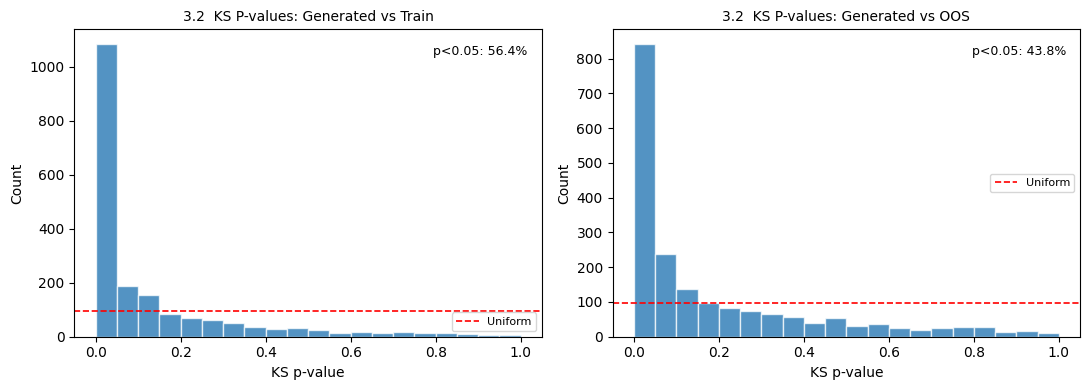

In [55]:
## 3.2 Distribution of KS Test P-values
pvals_gen_train, pvals_gen_oos = [], []
pvals_rs_train,  pvals_rs_oos  = [], []
pvals_gs_train,  pvals_gs_oos  = [], []
S = R_train.shape[1]
for s in range(S):
    g   = R_gen[:, s];      g   = g[np.isfinite(g)]
    rs  = R_rs[:, s];       rs  = rs[np.isfinite(rs)]
    gs  = R_gaussian[:, s]; gs  = gs[np.isfinite(gs)]
    tr  = R_train[:, s];    tr  = tr[np.isfinite(tr)]
    oos = R_test[:, s];     oos = oos[np.isfinite(oos)]
    if len(g)  > 5 and len(tr)  > 5: pvals_gen_train.append(ks_2samp(g,  tr).pvalue)
    if len(g)  > 5 and len(oos) > 5: pvals_gen_oos.append(  ks_2samp(g,  oos).pvalue)
    if len(rs) > 5 and len(tr)  > 5: pvals_rs_train.append( ks_2samp(rs, tr).pvalue)
    if len(rs) > 5 and len(oos) > 5: pvals_rs_oos.append(   ks_2samp(rs, oos).pvalue)
    if len(gs) > 5 and len(tr)  > 5: pvals_gs_train.append( ks_2samp(gs, tr).pvalue)
    if len(gs) > 5 and len(oos) > 5: pvals_gs_oos.append(   ks_2samp(gs, oos).pvalue)

pvals_gen_train = np.array(pvals_gen_train)
pvals_gen_oos   = np.array(pvals_gen_oos)
pvals_rs_train  = np.array(pvals_rs_train)
pvals_rs_oos    = np.array(pvals_rs_oos)
pvals_gs_train  = np.array(pvals_gs_train)
pvals_gs_oos    = np.array(pvals_gs_oos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for ax, pv, label in [(ax1, pvals_gen_train, "Generated vs Train"),
                      (ax2, pvals_gen_oos,   "Generated vs OOS")]:
    n_bins = 20
    ax.hist(pv, bins=n_bins, range=(0, 1), color="#1a6faf", alpha=0.75, edgecolor="white")
    ax.axhline(len(pv) / n_bins, color="red", linestyle="--", lw=1.2, label="Uniform")
    ax.set_xlabel("KS p-value", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"3.2  KS P-values: {label}", fontsize=10)
    ax.legend(fontsize=8)
    frac = (pv < 0.05).mean()
    ax.text(0.97, 0.95, f"p<0.05: {frac:.1%}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9)

fig.tight_layout()
plt.show()

In [56]:
col_w = 20
header = (f"{'':16}" + f"{'Generated':<{col_w}}"
          + f"{'Resample':<{col_w}}" + f"{'Gaussian':<{col_w}}")
print("KS p>0.05:")
print(header)
print("-" * len(header))
for label, pv_g, pv_r, pv_gs in [
    ("vs Train", pvals_gen_train, pvals_rs_train, pvals_gs_train),
    ("vs OOS",   pvals_gen_oos,   pvals_rs_oos,   pvals_gs_oos),
]:
    gen_val = f"{(pv_g  > 0.05).mean():.1%}"
    rs_val  = f"{(pv_r  > 0.05).mean():.1%}"
    gs_val  = f"{(pv_gs > 0.05).mean():.1%}"
    print(f"{label:<16}{gen_val:<{col_w}}{rs_val:<{col_w}}{gs_val:<{col_w}}")

KS p>0.05:
                Generated           Resample            Gaussian            
----------------------------------------------------------------------------
vs Train        43.6%               100.0%              30.2%               
vs OOS          56.2%               71.2%               45.1%               


In [57]:
beta_c    = train_model.beta[:, col_indices] # beta
res_std_c = train_model.res_std[col_indices]

# training part construction
sys_train  = train_model.F.values.astype(np.float32) @ beta_c
idio_train = train_model.residuals[:, col_indices].astype(np.float32)
# test part construction
test_beta_c = test_model.beta[:, col_indices_test]
sys_oos  = test_model.F.values.astype(np.float32) @ test_beta_c
idio_oos = test_model.residuals[:, col_indices_test].astype(np.float32)

In [58]:
assert np.allclose(sys_train + idio_train, R_train[1:, :], equal_nan=True)
assert np.allclose(sys_oos + idio_oos, R_test[1:, :], equal_nan=True)

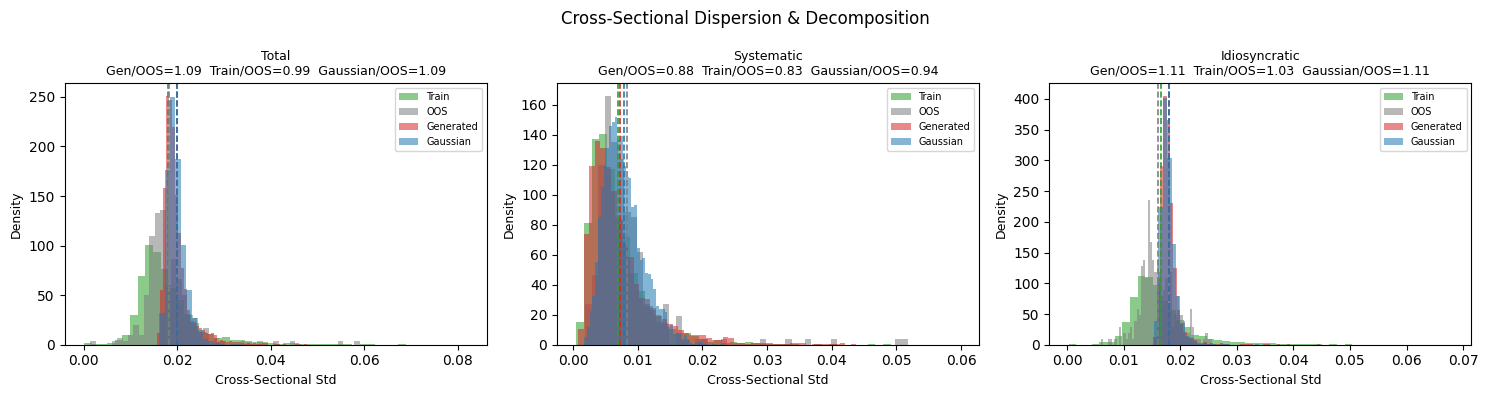

In [59]:
# helper: factor samples -> (sys, idio) for common stocks
def _decompose(sampler, num, model, beta_c, res_std_c, seed):
    fs_raw = sampler.generate(num).astype(np.float32)
    if model.factor_type == "regression":
        fs_full = np.column_stack([np.ones((len(fs_raw), 1)), fs_raw]).astype(np.float32)
    else:
        fs_full = fs_raw
    sys = fs_full @ beta_c
    t_noise = np.random.default_rng(seed).standard_t(model.res_df, size=sys.shape).astype(np.float32)
    idio = t_noise * np.sqrt((model.res_df - 2) / model.res_df) * res_std_c
    return sys, idio

sys_gen,      idio_gen      = _decompose(diffusionScenario.sampler, NUM_GENERATE, train_model, beta_c, res_std_c, seed=42)
sys_gaussian, idio_gaussian = _decompose(gaussionScenario.sampler,  NUM_GENERATE, train_model, beta_c, res_std_c, seed=1)

panels = [
    ("Total",         R_gen,    R_test,  R_train),
    ("Systematic",    sys_gen,  sys_oos, sys_train),
    ("Idiosyncratic", idio_gen, idio_oos, idio_train),
]

gs_mats = {
    "Total":         R_gaussian,
    "Systematic":    sys_gaussian,
    "Idiosyncratic": idio_gaussian,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (comp, gmat, omat, tmat) in zip(axes, panels):
    gsmat = gs_mats[comp]
    gv  = np.nanstd(gmat,  axis=1)
    gsv = np.nanstd(gsmat, axis=1)
    ov  = np.nanstd(omat,  axis=1)
    tv  = np.nanstd(tmat,  axis=1)
    ax.hist(tv,  bins=50, density=True, alpha=0.55, color="#2ca02c", label="Train")
    ax.hist(ov,  bins=50, density=True, alpha=0.55, color="#7f7f7f", label="OOS")
    ax.hist(gv,  bins=50, density=True, alpha=0.55, color="#d62728", label="Generated")
    ax.hist(gsv, bins=50, density=True, alpha=0.55, color="#1f78b4", label="Gaussian")
    for val, col in [(tv.mean(), "#2ca02c"), (ov.mean(), "#7f7f7f"),
                     (gv.mean(), "#d62728"), (gsv.mean(), "#1f78b4")]:
        ax.axvline(val, color=col, linestyle="--", lw=1.2)
    r_gen = gv.mean()  / (ov.mean() + 1e-12)
    r_tr  = tv.mean()  / (ov.mean() + 1e-12)
    r_gs  = gsv.mean() / (ov.mean() + 1e-12)
    ax.set_xlabel("Cross-Sectional Std", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.set_title(comp + "\nGen/OOS=%.2f  Train/OOS=%.2f  Gaussian/OOS=%.2f" % (r_gen, r_tr, r_gs), fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle("Cross-Sectional Dispersion & Decomposition", fontsize=12)
fig.tight_layout()
plt.show()

In [60]:
row_idx_r = row_idx[row_idx < len(sys_train)]
sys_rs    = sys_train[row_idx_r]
idio_rs   = idio_train[row_idx_r]

rs_panels = [
    ("Total",         R_rs,    R_test),
    ("Systematic",    sys_rs,  sys_oos),
    ("Idiosyncratic", idio_rs, idio_oos),
]

col_w = 20
header = (f"{'Component':<16}{'W1(Gen, OOS)':<{col_w}}"
          + f"{'W1(Gaussian, OOS)':<{col_w}}{'W1(Resample, OOS)':<{col_w}}")
print("Wasserstein-1 Distance of Cross-Sectional Std (vs OOS):")
print(header)
print("-" * len(header))
for (comp, gmat, omat, _), (_, rsmat, _) in zip(panels, rs_panels):
    gsmat = gs_mats[comp]
    gv  = np.nanstd(gmat,  axis=1); gv  = gv[np.isfinite(gv)]
    gsv = np.nanstd(gsmat, axis=1); gsv = gsv[np.isfinite(gsv)]
    ov  = np.nanstd(omat,  axis=1); ov  = ov[np.isfinite(ov)]
    rsv = np.nanstd(rsmat, axis=1); rsv = rsv[np.isfinite(rsv)]
    print(f"{comp:<16}{w1dist(gv, ov):<{col_w}.4f}{w1dist(gsv, ov):<{col_w}.4f}{w1dist(rsv, ov):<{col_w}.4f}")

Wasserstein-1 Distance of Cross-Sectional Std (vs OOS):
Component       W1(Gen, OOS)        W1(Gaussian, OOS)   W1(Resample, OOS)   
----------------------------------------------------------------------------
Total           0.0023              0.0029              0.0013              
Systematic      0.0013              0.0010              0.0014              
Idiosyncratic   0.0022              0.0022              0.0014              
